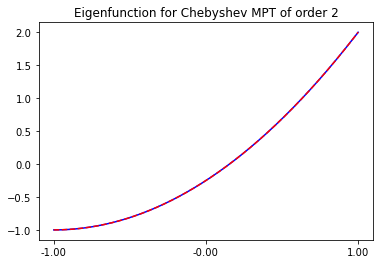

-0.250000000000000


In [55]:
%run ../python/chebyshevMPT.py
from numpy import linspace, mean
from numpy.polynomial import Polynomial
import sympy as sp
import matplotlib.pyplot as plt
from functools import partial


order = 2
chebym = ChebyshevMPT(order)
u = linspace(-1.0+1e-8,1.0-1e-8,num=1000, endpoint=True)

# Proposed eigenfunction as polynomials
p = Polynomial([-1, 6, 3])
d = p.degree()
lambdad = 1/(2**d)

Pf = [chebym.FP(p,u1) for u1 in u]
flam = [lambdad*p(u1) for u1 in u]
fig, ax = plt.subplots()
ax.plot(u,Pf, label='Pf', color='blue')
ax.plot(u, flam, label='$\\lambda f$', color='red', linestyle="--")
ax.set_title(f"Eigenfunction for Chebyshev MPT of order {order}")
ax.set_xticks(chebym.extrema)
extrstr = ["{:.2f}".format(x) for x in chebym.extrema]
ax.set_xticklabels(extrstr)
plt.show()

print(sp.euler(2,0.5))

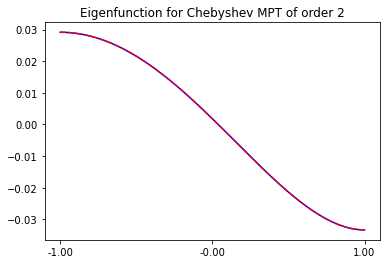

In [56]:
# This chunk implements the spectral decomposition provided
# by Claude 5.0 on September 13, 2026.
#
# Note that there is a sign discrepancy so the given function
# is not actually an eigenfunction. Something is wrong. 

def pB(x,deg):
    return (sp.bernoulli(deg,(1+x)/2) -
            (deg/2)*sp.euler(deg-1,(1+x)/2))

d = 4
Pf = [chebym.FP(partial(pB, deg=d),u1) for u1 in u]
flam = [(0.5**d)*pB(-u1,d) for u1 in u]

fig, ax = plt.subplots()
ax.plot(u,Pf, label='Pf', color='blue')
ax.plot(u, flam, label='$\\lambda f$', color='red', linestyle="--")
ax.set_title(f"Eigenfunction for Chebyshev MPT of order {order}")
ax.set_xticks(chebym.extrema)
extrstr = ["{:.2f}".format(x) for x in chebym.extrema]
ax.set_xticklabels(extrstr)
plt.show()
